In [1]:
# Imports: 
#Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import scipy.stats as stats 
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import tkinter as tk
from tkinter import filedialog
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [8]:
# get x_data,y_data

def split_file(file_path, rows):
    data = np.loadtxt(file_path, skiprows=rows)
        
    x_data = data[:, 0]
    y_data = data[:, 1]
    return x_data,y_data

In [3]:
# Single gaussian fns
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))


def fit_gaussian_from_dataset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    - x_fit: x_fitting array
    - y_fit: fitted gaussian curve
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess = [max(y_data), np.mean(x_data), np.std(x_data)]
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        
        # Extract fitted parameters
        A_fit, mu_fit, sigma_fit = popt
        # Print the fitted parameters for feedback
        #print(f"Fitted parameters:\nAmplitude: {A_fit}\nMean: {mu_fit}\nSigma: {sigma_fit}")
        #print(f"Raw data parameters are:\n Min = {min_raw}\n Mean = {mean_raw}\n Max = {max_raw}")
        y_fit=gaussian(x_fit,*popt)
        # Return the fitted parameters and covariance matrix
        return popt, pcov, x_fit,y_fit

    except Exception as e:
        print(f"Error fitting Gaussian: {e}")
        return None, None, None, None, None

In [4]:
# Multi-gaussian def + process:
# Function to model N Gaussians
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        amp = params[i * 3]
        cen = params[i * 3 + 1]
        wid = params[i * 3 + 2]
        y += amp * np.exp(-((x - cen) ** 2) / (2 * wid ** 2))
    return y

# Auto-generate initial guess based on data
def estimate_guess_from_data(x, y, prominence=0.1, distance=10):
    y_smooth = gaussian_filter1d(y, sigma=2)
    peaks, _ = find_peaks(y_smooth, prominence=prominence, distance=distance)
    
    # Sort peaks by height (amplitude) and limit to top 2
    if len(peaks) > 2:
        sorted_indices = np.argsort(properties['prominences'])[::-1][:2]
        peaks = peaks[sorted_indices]

    guess = []
    for i in peaks:
        amp = y[i]
        cen = x[i]
        wid = 0.001 # Adjust based on data
        guess += [amp, cen, wid]
    
    return guess, len(peaks)

def multigaussian_fit_from_datset(x_data, y_data):
    """
    Fit a Gaussian curve to the provided dataset (x_data, y_data).
    Args:
    - x_data: Array-like, x values of the data
    - y_data: Array-like, y values of the data
    
    Returns:
    - popt: Optimal parameters from curve fitting
    - pcov: Covariance matrix
    - x_fit: x_fitting array
    - y_fit: fitted gaussian curve
    """
    # Initial guess for the parameters [A, mu, sigma]
    initial_guess, n_peaks = estimate_guess_from_data(x_data, y_data)
    x_fit= np.linspace(np.min(x_data), np.max(x_data), 1000000)
    if n_peaks is not None: 
        print("Found peaks")

    try:
        # Fit the Gaussian curve to the data
        popt, pcov = curve_fit(multi_gaussian, x_data, y_data, p0=initial_guess, maxfev=100000000)
        y_fit=multi_gaussian(x_fit,*popt)

        # Return the fitted parameters and covariance matrix
        return popt, pcov, x_fit,y_fit

    except Exception as e:
        print(f"Error fitting Multigaussian: {e}")
        return None, None, None, None, None

In [20]:
# Plotting for GB,GI+full:
def plotting_individual(x_data,y_data,x_fit, y_fit):
    #Plotting parameters
    dpi_setting = 600
    figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
    tick_length = 6 
    legend_font = 12
    scatter_size = 18
    base_font_size = 12
    line_width = 3

    fig,ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
    plt.rcParams.update({'font.size': base_font_size}) # Use a slightly smaller font for general text
    
    ax.tick_params(direction='in', length=tick_length, labelsize=base_font_size)
    ax.tick_params(axis='both')#, labelsize=18)
    ax.margins(0.05, 0.05) # Reduced margins for a tighter plot
    ax.set_xlabel(f"CPD (V)")#, fontsize=22)
    
    # Calculate limits from all fitted data for consistent scaling
    x_data_all = np.concatenate([x_data,x_fit])
    ax.set_xlim(np.min(x_data_all) - 0.01, np.max(x_data_all) + 0.01)
    ax.set_ylabel("Distribution (V$^{-1}$)")#, fontsize=22)
    
    # Limit number of ticks
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    
    # Plotting
    plt.scatter(x_data, y_data, label=f"Raw Data", s=scatter_size)
    plt.plot(x_fit, y_fit, label=f"Fitting", linewidth=line_width)
    

    return
    plt.show()

In [49]:
# Set file paths

boundary_txt = r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\CPD_Final\CPD_ForProcessing\Unpassivated\250422_CTRL_RG0087\GB\1.txt"
interior_txt = r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\CPD_Final\CPD_ForProcessing\Unpassivated\250422_CTRL_RG0087\GI\1.txt"
full_txt=r"X:\ramadan_group\Group Members\Rehmat Goodwin\Lab Data\Processed Data\25_03_12_FACs_HK_Batch1\1 - KPFM\Grain Analysis\CPDHistogramsForAnnotation\Control\250422_Control_5um_CPDR_Histogram.txt"

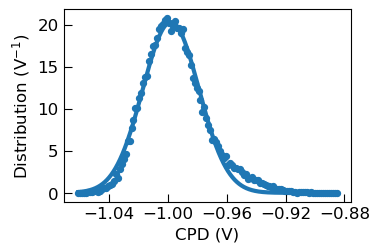

In [50]:
# Interior
# Split files
x_interior,y_interior = split_file(interior_txt,3)
# Fitting
popt_interior, pcov_interior, x_fit_interior, y_fit_interior=fit_gaussian_from_dataset(x_interior, y_interior)
# Plotting
plotting_individual(x_interior,y_interior, x_fit_interior, y_fit_interior)


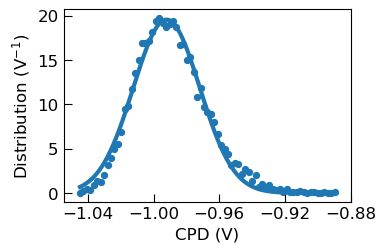

In [51]:
# Boundary: 
# Call file
x_boundary,y_boundary = split_file(boundary_txt,3)
#Fitting
popt_boundary, pcov_boundary, x_fit_boundary, y_fit_boundary=fit_gaussian_from_dataset(x_boundary, y_boundary)
# Plotting
plotting_individual(x_boundary,y_boundary,x_fit_boundary, y_fit_boundary)

Found peaks


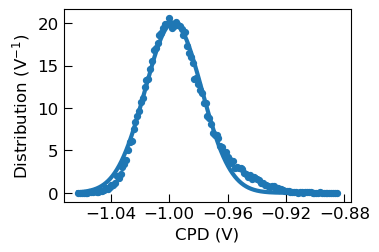

In [52]:
# Full image
# Call file
x_full,y_full = split_file(full_txt,3)
#Multigaussian fit
popt_full, pcov_full, x_fit_full, y_fit_full=multigaussian_fit_from_datset(x_full, y_full)
# Plotting
plotting_individual(x_full,y_full,x_fit_full, y_fit_full)


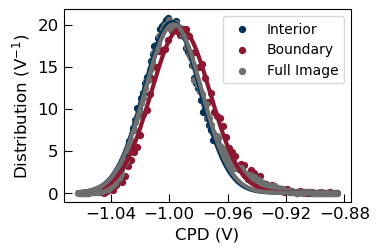

In [53]:
# Plotting all: 

dpi_setting = 600
figsize_x, figsize_y = (2227/dpi_setting), (1498/dpi_setting)
tick_length = 6 
legend_font = 10
scatter_size = 18
base_font_size = 12
line_width = 3


fig,ax = plt.subplots(1, 1, sharey=True, figsize=(figsize_x, figsize_y))
plt.rcParams.update({'font.size': base_font_size}) # Use a slightly smaller font for general text
    
ax.tick_params(direction='in', length=tick_length, labelsize=base_font_size)
ax.tick_params(axis='both')
ax.margins(0.05, 0.05) # Reduced margins for a tighter plot
ax.set_xlabel(f"CPD (V)")
ax.set_ylabel("Distribution (V$^{-1}$)")    

# Calculate limits from all fitted data for consistent scaling
x_data_all = np.concatenate([x_interior,x_fit_interior, x_boundary, x_fit_boundary,x_full,x_fit_full])
ax.set_xlim(np.min(x_data_all) - 0.01, np.max(x_data_all) + 0.01)

# Limit number of ticks
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5)) 
    
# Interior: 
plt.scatter(x_interior, y_interior, label=f"Interior",color = "#003357", s=scatter_size)
plt.plot(x_fit_interior, y_fit_interior, label=f"_nolabel_", color = "#003357", linewidth=line_width)

# Boundary: 
plt.scatter(x_boundary, y_boundary, label=f"Boundary", color = "#8D1730" , s=scatter_size)
plt.plot(x_fit_boundary, y_fit_boundary, label=f"_nolabel_",color = "#8D1730" ,linewidth=line_width)


# Full:
plt.scatter(x_full, y_full, label=f"Full Image", color = "#6F6F6F" ,s=scatter_size)
plt.plot(x_fit_full, y_fit_full, label=f"_nolabel_", color = "#6F6F6F" , linewidth=line_width)
plt.legend(fontsize=legend_font, loc='best')

plt.show()

In [ ]:
# Pull out statistics: